# **IBL brain-wide map dataset**

## Installation and setup

The code blocks in this section install and import required packages. We also define a set of utility functions that will be used to download and load data throughout the rest of the tutorial. **Make sure these cells are run before continuing onto the next sections.**

### **Install dependencies**

In [19]:
! pip install ONE-api --quiet
! pip install ibllib --quiet

### **Setup ONE**

In [20]:
# When running in jupyter set number of threads to 1
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

from one.api import ONE
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


### **Define imports**

In [21]:
!pip install quantities
!pip install neo
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd
from scipy import sparse
import numpy as np
from one.remote.aws import s3_download_file
import zipfile
import tqdm
import scipy.stats as stats
from iblutil.util import Bunch
from scipy.ndimage import gaussian_filter1d
import quantities as pq
import neo

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# This is to view dataframe interactively in Google colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures
if sys.version_info >= (3, 10):
    from ibl_style.style import figure_style
    figure_style()

### **Define loading utility functions**

In [22]:
def download_data(event):
  assert event in ['firstMove', 'stimOn', 'feedback'], 'event must be one of "firstMove", "stimOn" or "feedback'

  # Dataset name
  fname = f'data_{event}.zip'
  # Remote location of data
  s3_data_path = f'sample_data/Neuromatch/{fname}'
  # Local location to download data to
  save_path = one.cache_dir.joinpath('Neuromatch', fname)
  save_path.parent.mkdir(exist_ok=True, parents=True)

  # Download file
  file = s3_download_file(s3_data_path, save_path)
  # Unzip content
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(save_path.parent)


def get_data_path(event):

  return one.cache_dir.joinpath('Neuromatch', f'data_{event}')


def load_metadata(event):
  metadata = Bunch()
  data_path = get_data_path(event)
  metadata['clusters'] = pd.read_parquet(data_path.joinpath('clusters.pqt'))
  metadata['trials'] = pd.read_parquet(data_path.joinpath('trials.pqt'))
  metadata['sessions'] = pd.read_parquet(data_path.joinpath('sessions.pqt'))
  metadata['times'] = np.load(data_path.joinpath('t.npy'))
  metadata['nbins'] = metadata['times'].size
  metadata['dt'] = np.round(np.median(np.diff(metadata['times'])), 2)
  metadata['data_path'] = data_path

  return metadata


def load_times(data_path):
  return np.load(data_path.joinpath('t.npy'))


def load_psth(data_path, pid, nbins=150):
    psth = sparse.load_npz(data_path.joinpath(f'{pid}.npz')).toarray()
    psth = psth.reshape(psth.shape[0], -1, nbins)
    return psth

### **Define processing utility functions** <a name="Utility-functions"></a>

In [23]:
def split_trials_by_variable(trials, split='contrast'):
  trials = trials.set_index('psth_index')
  if split == 'contrast':
    trials['contrast'] = np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('contrast')
  elif split == 'signed contrast':
    trials['signedContrast'] = np.nansum([-1 * trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('signedContrast')
  elif split == 'stimulus':
    trials['stimulus'] = 'right'
    trials.loc[trials['contrastRight'].isna(), 'stimulus'] = 'left'
    grp = trials.groupby('stimulus')
  elif split == 'choice':
    grp = trials.groupby('choice')
  elif split == 'block':
    grp = trials.groupby('probabilityLeft')
  else:
    raise NotImplementedError('split must be one of "contrast", "signed contrast", "stimulus", "choice" or "block"')

  return grp.groups


def get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  if split is None:
    psth = sp.mean(axis=0) / meta['dt']
  else:
    psth = dict()
    eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
    trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
    grps = split_trials_by_variable(trials, split=split)

    for key, vals in grps.items():
      psth[key] = sp[vals, :, :].mean(axis=0)

  return psth, df

def get_avg_psth_for_region(reg, meta, split=None):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, reg=reg, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}


  return all_psth, all_df


def get_avg_psth_for_clusters(uuids, meta, split=None):
  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, uuids=uuids, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}

  return all_psth, all_df



def get_psth_for_insertion(pid, meta, reg=None, uuids=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)


  eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
  trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
  psth = sp / meta['dt']

  return psth, df, trials


def get_psth_for_region(reg, meta):

  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, reg=reg)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials


def get_psth_for_clusters(uuids, meta):

  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, uuids=uuids)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials

# GPFA


## Install Dependencies

In [10]:
!pip install elephant

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 712.5/712.5 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.0/104.0 kB 5.6 MB/s eta 0:00:00


In [11]:
from elephant.gpfa import GPFA

## Collect Data

In [25]:
# Download movement-aligned metadata

download_data('firstMove')
meta = load_metadata('firstMove')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_firstMove.zip: 100%|██████████| 823M/823M [00:09<00:00, 82.6MB/s]


## Filter by region

Find insertion from each region of choice with the largest numbers of clusters and add it's data to a dictionary.

In [ ]:
regions = ['GRN', 'RPF', 'MOs', 'MOB']  # your regions of interest

region_data = {}

for region in regions:
    counts = meta.clusters[meta.clusters['acronym'] == region]['pid'].value_counts()
    if len(counts) == 0:
        print(f"{region}: no clusters found, skipping")
        continue

    top_pid = counts.idxmax()
    print(f"{region}: using pid {top_pid} ({counts.max()} clusters)")

    psth, clust, trials = get_psth_for_insertion(top_pid, meta, reg=region)

    region_data[region] = {
        'pid': top_pid,
        'psth': psth,
        'clust': clust,
        'trials': trials
    }

print("Regions collected:", list(region_data.keys()))

GRN: using pid cc72fdb7-92e8-47e6-9cea-94f27c0da2d8 (79 clusters)
RPF: using pid d3b3c9a7-cf6a-4d25-b8da-e0f599a26191 (14 clusters)
MOs: using pid ea084e63-c0cb-4e11-8440-302de8fc76ee (73 clusters)
MOB: using pid 6638cfb3-3831-4fc2-9327-194b76cf22e1 (125 clusters)
Regions collected: ['GRN', 'RPF', 'MOs', 'MOB']


In [ ]:
pre_mov_time_window = meta.times < 0

for region, data in region_data.items():
    psth = data['psth']
    trials = data['trials']

    left_idxs = trials[trials['choice'] == -1.0].index
    right_idxs = trials[trials['choice'] == 1.0].index

    left_trials = psth[left_idxs, :, :]
    right_trials = psth[right_idxs, :, :]

    # Trim to pre-movement window
    left_trials = left_trials[:, :, pre_mov_time_window]
    right_trials = right_trials[:, :, pre_mov_time_window]

    # Store back into the dict
    data['left_trials'] = left_trials
    data['right_trials'] = right_trials

    print(f"{region}: left {left_trials.shape}, right {right_trials.shape}")
print("\nFormat: (n_trials, n_clusters, n_bins)")

GRN: left (298, 79, 50), right (263, 79, 50)
RPF: left (304, 14, 50), right (265, 14, 50)
MOs: left (176, 73, 50), right (386, 73, 50)
MOB: left (167, 125, 50), right (174, 125, 50)

Format: (n_trials, n_clusters, n_bins)


In [ ]:
dt = meta['dt']

def bins_to_spiketrains(binned_trials, dt, round_decimals=9):
    n_bins = binned_trials.shape[2]
    all_spiketrains = []

    for trial in binned_trials:
        counts = np.round(trial * dt).astype(int)
        trial_sts = []
        for neuron in range(counts.shape[0]):
            spike_times = []
            for b in range(n_bins):
                n = counts[neuron, b]
                if n > 0:
                    times = np.linspace(b * dt, (b + 1) * dt, n, endpoint=False)
                    spike_times.extend(times)
            spike_times = np.round(np.sort(spike_times), decimals=round_decimals)
            st = neo.SpikeTrain(
                spike_times * pq.s,
                t_start=0 * pq.s,
                t_stop=round(n_bins * dt, round_decimals) * pq.s
            )
            trial_sts.append(st)
        all_spiketrains.append(trial_sts)

    return all_spiketrains


for region, data in region_data.items():
    data['spiketrains_left'] = bins_to_spiketrains(data['left_trials'], dt)
    data['spiketrains_right'] = bins_to_spiketrains(data['right_trials'], dt)
    print(f"{region}: converted {len(data['spiketrains_left'])} left trials, "
          f"{len(data['spiketrains_right'])} right trials")

GRN: converted 298 left trials, 263 right trials
RPF: converted 304 left trials, 265 right trials
MOs: converted 176 left trials, 386 right trials
MOB: converted 167 left trials, 174 right trials


In [ ]:
gpfa_results = {}

for region, data in region_data.items():
    spiketrains_left = data['spiketrains_left']
    spiketrains_right = data['spiketrains_right']

    gpfa = GPFA(bin_size=dt * pq.s, x_dim=8)

    trajectories = gpfa.fit_transform(spiketrains_left + spiketrains_right)

    n_left = len(spiketrains_left)
    traj_left_trials = trajectories[:n_left]
    traj_right_trials = trajectories[n_left:]

    gpfa_results[region] = {
        'pid': data['pid'],
        'gpfa_model': gpfa,
        'traj_left_trials': traj_left_trials,
        'traj_right_trials': traj_right_trials
    }

    print(f"{region}: fit GPFA on {n_left} left + {len(traj_right_trials)} right trials")

print("\nRegions with GPFA results:", list(gpfa_results.keys()))

Streaming output truncated to the last 5000 lines.
[2026-07-21 16:11:31,531] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-21 16:11:31,532] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-21 16:11:31,535] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-21 16:11:31,537] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-21 16:11:31,563] utils - WARNING: Correcting 1 rounding errors by shifting the affected spikes into the following bin. You can set tolerance=None to disable this behaviour.
[2026-07-21 16:11:31,566] utils - WARNI

Initializing parameters using factor analysis...

Fitting GPFA model...


In [8]:
import shutil
shutil.rmtree('/content/drive', ignore_errors=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import pickle

with open('/content/drive/MyDrive/gpfa_results.pkl', 'rb') as f:
    gpfa_results = pickle.load(f)

print(list(gpfa_results.keys()))

['GRN', 'RPF', 'MOs', 'MOB']


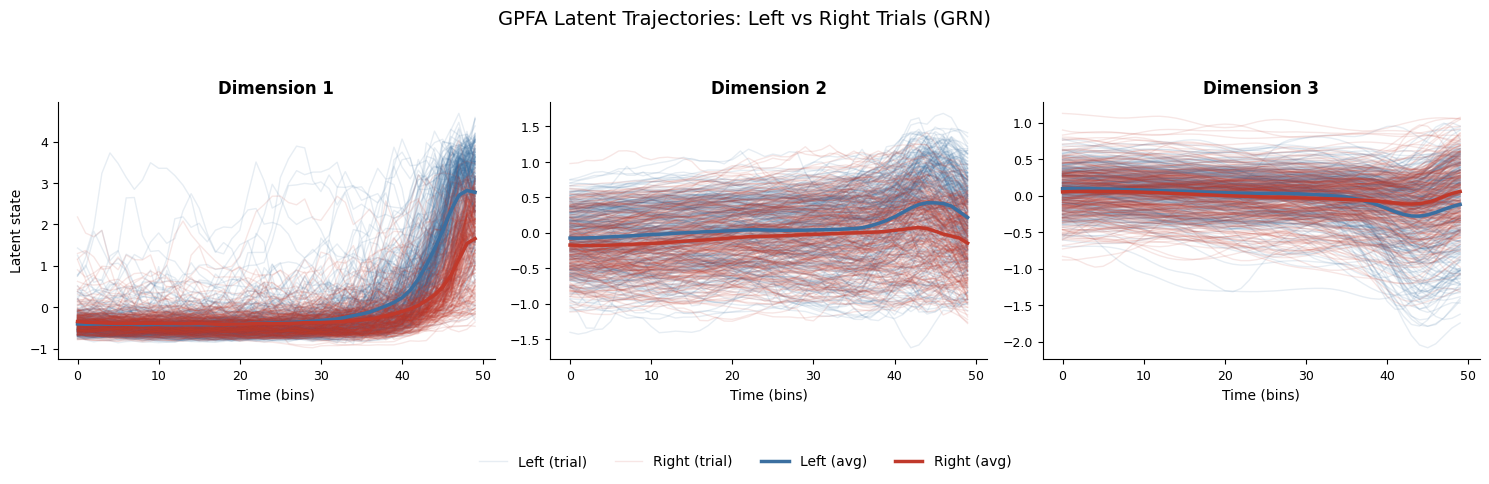

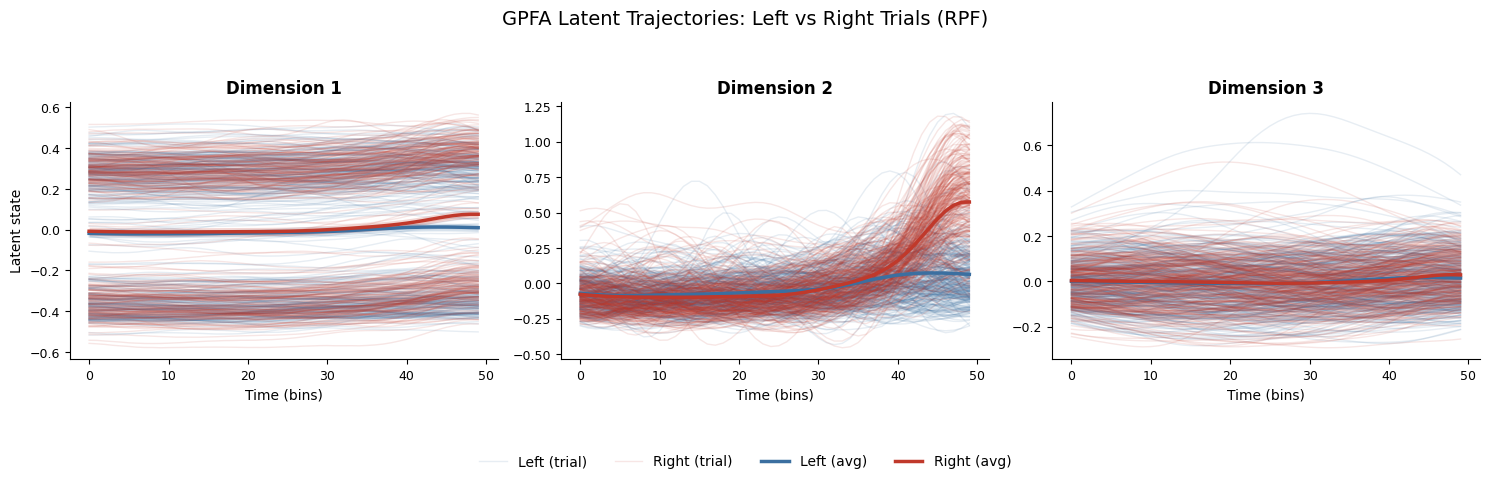

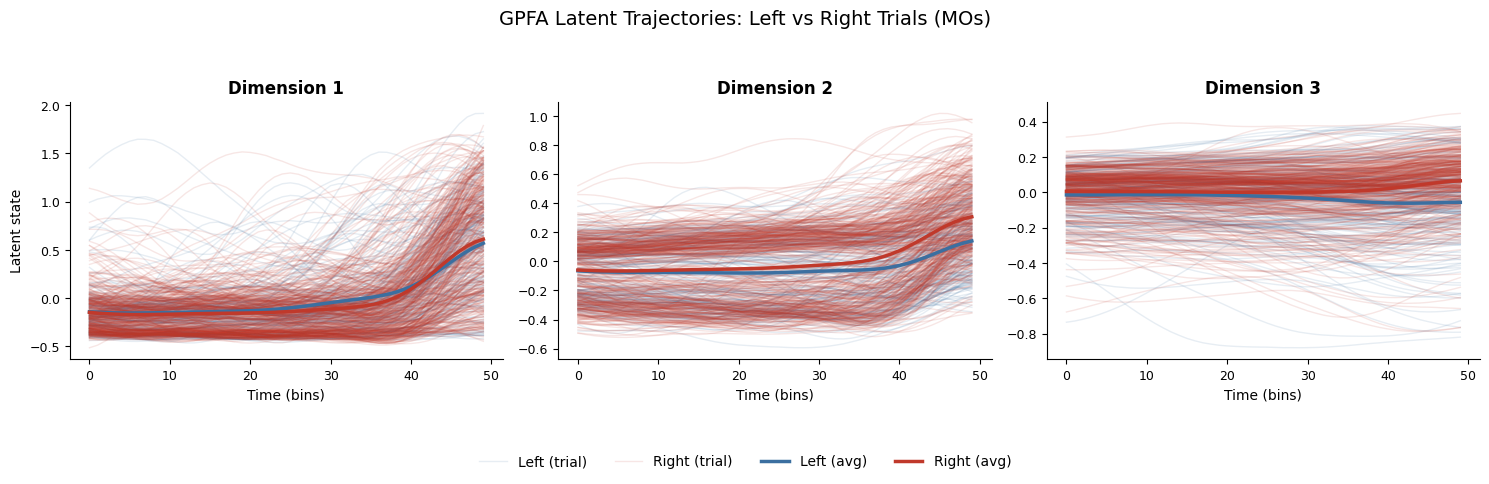

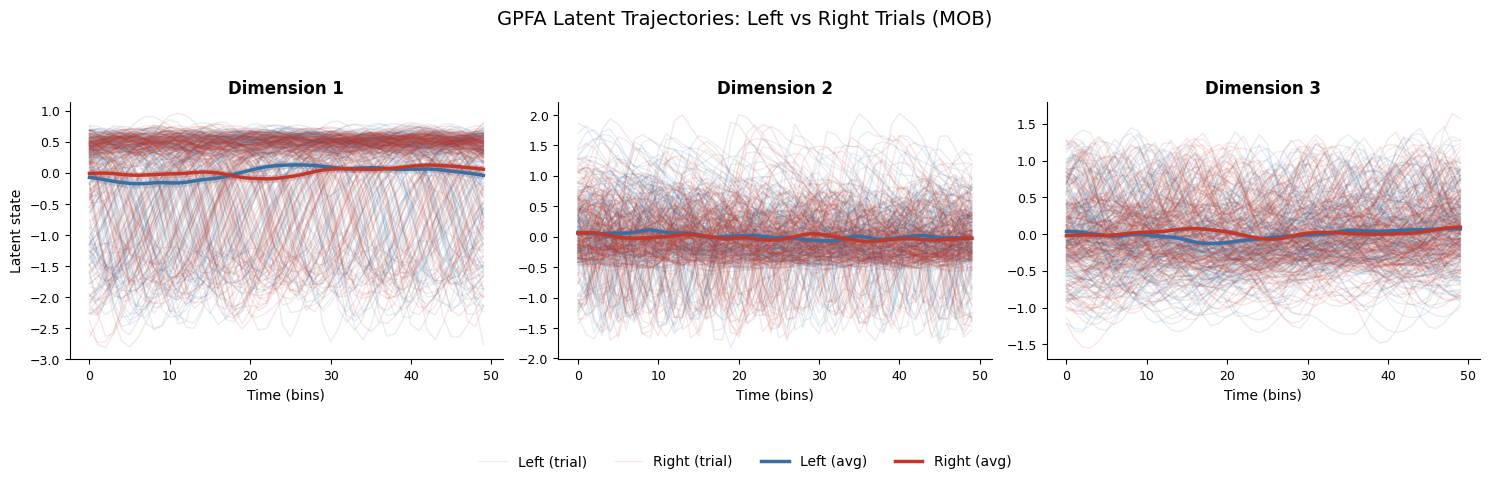

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_gpfa_trajectories(traj_left_trials, traj_right_trials, region_name, n_dims_to_plot=3):
    left_arr = np.stack(traj_left_trials, axis=0)    # (n_trials, x_dim, n_bins)
    right_arr = np.stack(traj_right_trials, axis=0)

    avg_left = left_arr.mean(axis=0)   # (x_dim, n_bins)
    avg_right = right_arr.mean(axis=0)
    sem_left = left_arr.std(axis=0) / np.sqrt(left_arr.shape[0])
    sem_right = right_arr.std(axis=0) / np.sqrt(right_arr.shape[0])

    color_left, color_right = '#3B6FA0', '#C0392B'

    fig, axes = plt.subplots(1, n_dims_to_plot, figsize=(15, 4.2), sharex=True)
    if n_dims_to_plot == 1:
        axes = [axes]  # keep iterable if only plotting 1 dim

    for dim, ax in enumerate(axes):
        time = np.arange(avg_left.shape[1])

        for i, traj in enumerate(traj_left_trials):
            ax.plot(time, traj[dim, :], color=color_left, alpha=0.12, lw=1,
                     label='Left (trial)' if i == 0 else None)
        for i, traj in enumerate(traj_right_trials):
            ax.plot(time, traj[dim, :], color=color_right, alpha=0.12, lw=1,
                     label='Right (trial)' if i == 0 else None)

        ax.plot(time, avg_left[dim, :], color=color_left, lw=2.5, label='Left (avg)')
        ax.fill_between(time, avg_left[dim, :] - sem_left[dim, :],
                         avg_left[dim, :] + sem_left[dim, :],
                         color=color_left, alpha=0.2, linewidth=0)

        ax.plot(time, avg_right[dim, :], color=color_right, lw=2.5, label='Right (avg)')
        ax.fill_between(time, avg_right[dim, :] - sem_right[dim, :],
                         avg_right[dim, :] + sem_right[dim, :],
                         color=color_right, alpha=0.2, linewidth=0)

        ax.set_title(f'Dimension {dim + 1}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (bins)', fontsize=10)
        if dim == 0:
            ax.set_ylabel('Latent state', fontsize=10)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(labelsize=9)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=False,
               bbox_to_anchor=(0.5, 0.02), fontsize=10)

    fig.suptitle(f'GPFA Latent Trajectories: Left vs Right Trials ({region_name})',
                 y=1.05, fontsize=14)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


# Loop over all regions
for region, data in gpfa_results.items():
    plot_gpfa_trajectories(
        data['traj_left_trials'],
        data['traj_right_trials'],
        region_name=region,
        n_dims_to_plot=3
    )

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def first_sustained_crossing(above_null, min_run=3):
    """First index where `min_run` consecutive bins are all True."""
    run_length = 0
    for i, val in enumerate(above_null):
        run_length = run_length + 1 if val else 0
        if run_length >= min_run:
            return i - min_run + 1
    return None


def decode_region(traj_left_trials, traj_right_trials, dt, n_permutations=500, seed=0):
    n_bins = traj_left_trials[0].shape[1]
    x_dim = traj_left_trials[0].shape[0]

    traj_all = np.stack(list(traj_left_trials) + list(traj_right_trials))  # (n_trials, x_dim, n_bins)
    y = np.array([0]*len(traj_left_trials) + [1]*len(traj_right_trials))

    rng = np.random.default_rng(seed)

    real_acc = np.zeros(n_bins)
    null_accs = np.zeros((n_bins, n_permutations))
    chosen_Cs = np.zeros(n_bins)

    for t in range(n_bins):
        X_t = traj_all[:, :, t]

        # Step 1: pick C once via nested CV on the real data
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
        clf_cv = make_pipeline(
            StandardScaler(),
            LogisticRegressionCV(
                Cs=10, cv=3, penalty='l1', solver='liblinear',
                max_iter=1000, scoring='accuracy'
            )
        )
        real_acc[t] = cross_val_score(clf_cv, X_t, y, cv=cv).mean()

        clf_cv.fit(X_t, y)
        chosen_Cs[t] = clf_cv.named_steps['logisticregressioncv'].C_[0]

        # Step 2: fixed-C permutations (fast)
        for i in range(n_permutations):
            y_shuffled = rng.permutation(y)
            cv_perm = StratifiedKFold(n_splits=5, shuffle=True, random_state=i)
            clf_perm = make_pipeline(
                StandardScaler(),
                LogisticRegression(penalty='l1', solver='liblinear',
                                    C=chosen_Cs[t], max_iter=1000)
            )
            null_accs[t, i] = cross_val_score(clf_perm, X_t, y_shuffled, cv=cv_perm).mean()

    null_ci_upper = np.percentile(null_accs, 97.5, axis=1)
    above_null = real_acc > null_ci_upper
    first_bin_robust = first_sustained_crossing(above_null, min_run=3)

    time = (np.arange(n_bins) - (n_bins - 1)) * dt
    first_time_robust = time[first_bin_robust] if first_bin_robust is not None else None

    return {
        'real_acc': real_acc,
        'null_accs': null_accs,
        'null_ci_upper': null_ci_upper,
        'above_null': above_null,
        'chosen_Cs': chosen_Cs,
        'time': time,
        'first_bin_robust': first_bin_robust,
        'first_time_robust': first_time_robust
    }


# --- Run for every region ---
decoding_results = {}

for region, data in gpfa_results.items():
    print(f"Decoding region: {region}...")
    result = decode_region(
        data['traj_left_trials'],
        data['traj_right_trials'],
        dt=meta.dt,
        n_permutations=500
    )
    decoding_results[region] = result

    if result['first_time_robust'] is not None:
        print(f"  -> First sustained above-chance decoding at t = {result['first_time_robust']:.3f} s")
    else:
        print(f"  -> No sustained above-chance crossing found")

print("\nDone. Regions processed:", list(decoding_results.keys()))

Decoding region: GRN...
